In [593]:
import pandas as pd
import numpy as np

In [594]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\data\processed\ProcessedObservedData.csv')
#filter by opDiv CDC
data = data[data['OpDiv'] == 'CDC']
data.drop(columns=['curr_date', 'OpDiv'], inplace=True)
# Rename the index to 'date' since 'obs_date' is now the index
data.rename(columns={'obs_date': 'date'}, inplace=True)
data.reset_index(drop=True, inplace=True)
data.head(10)
# Create a copy of the relevant columns to avoid SettingWithCopyWarning

data.head(10)

,indicator,API_UserName,date,observations
0,146.71.50.198,00818860012482918321,2025-01-01,1
1,149.36.49.225,00818860012482918321,2025-01-01,28
2,162.142.125.242,00818860012482918321,2025-01-01,3
3,162.142.125.247,00818860012482918321,2025-01-01,2
4,162.142.125.255,00818860012482918321,2025-01-01,3
5,185.230.63.171,00818860012482918321,2025-01-01,6
6,23.26.221.12,00818860012482918321,2025-01-01,49
7,23.26.221.2,00818860012482918321,2025-01-01,51
8,23.26.221.4,00818860012482918321,2025-01-01,36
9,34.160.111.145,00818860012482918321,2025-01-01,4


In [595]:
data['date'] = pd.to_datetime(data['date'])

# Define ranges for combinations
all_users = data['API_UserName'].unique()  # Unique API_UserName
all_indicators = data['indicator'].unique()  # Unique indicators
all_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')  # Full year of 2025

# Create all combinations
all_combinations = pd.MultiIndex.from_product(
    [all_users, all_dates, all_indicators],
    names=['API_UserName', 'date', 'indicator']
).to_frame(index=False)

# Merge with the existing data
merged = all_combinations.merge(data, how='left', on=['API_UserName', 'date', 'indicator'])

# Fill missing values in 'observations' with 0 (not seen)
merged['observations'] = merged['observations'].fillna(0).astype(int)

# Display the first few rows of the merged dataset
print(merged.head())

           API_UserName       date        indicator  observations
0  00818860012482918321 2025-01-01    146.71.50.198             1
1  00818860012482918321 2025-01-01    149.36.49.225            28
2  00818860012482918321 2025-01-01  162.142.125.242             3
3  00818860012482918321 2025-01-01  162.142.125.247             2
4  00818860012482918321 2025-01-01  162.142.125.255             3


In [596]:
# Convert the 'date' column to datetime format
merged['date'] = pd.to_datetime(merged['date'])

# Extract day of the week (0=Monday, 6=Sunday)
merged['dayofweek'] = merged['date'].dt.dayofweek

# Determine if the day is a weekend (Saturday=5, Sunday=6)
merged['is_weekend'] = merged['dayofweek'].isin([5, 6])

# Extract additional features if needed
merged['day'] = merged['date'].dt.day
merged['month'] = merged['date'].dt.month


In [597]:
merged['observations'].min()

np.int64(0)

In [ ]:
merged['seen'] = (merged['observations'] > 0).astype(int)
merged.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
0,00818860012482918321,2025-01-01,146.71.50.198,1,2,False,1,1,1
1,00818860012482918321,2025-01-01,149.36.49.225,28,2,False,1,1,1
2,00818860012482918321,2025-01-01,162.142.125.242,3,2,False,1,1,1
3,00818860012482918321,2025-01-01,162.142.125.247,2,2,False,1,1,1
4,00818860012482918321,2025-01-01,162.142.125.255,3,2,False,1,1,1
5,00818860012482918321,2025-01-01,185.230.63.171,6,2,False,1,1,1
6,00818860012482918321,2025-01-01,23.26.221.12,49,2,False,1,1,1
7,00818860012482918321,2025-01-01,23.26.221.2,51,2,False,1,1,1
8,00818860012482918321,2025-01-01,23.26.221.4,36,2,False,1,1,1
9,00818860012482918321,2025-01-01,34.160.111.145,4,2,False,1,1,1


In [ ]:
# Filter for the last 90 days
cutoff_date = merged['date'].max() - pd.Timedelta(days=90)
filtered_records = merged[merged['date'] >= cutoff_date]

In [607]:
cutoff_date

Timestamp('2025-10-02 00:00:00')

In [600]:
# Set up lag features for 'seen'
for lag in [1, 3]:  # Use smaller lags
    filtered_records[f'seen_lag_{lag}'] = (
        filtered_records.groupby(['API_UserName', 'indicator'])['seen']
        .shift(lag)
    )

# Rolling features for 'observations'
filtered_records['obs_roll_3'] = (
    filtered_records.groupby(['API_UserName', 'indicator'])['observations']
    .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

# Define a dynamic look-back function
def dynamic_lookback(group, lookback_days=15):
    """
    Filters the group to include only rows within the look-back period.
    The look-back period starts from the last 'Seen' event.
    """
    last_seen_date = group[group['seen'] == 1]['date'].max()
    if pd.isna(last_seen_date):
        # If no 'Seen' event exists, return an empty DataFrame
        return group.iloc[0:0]
    cutoff_date = last_seen_date - pd.Timedelta(days=lookback_days)
    return group[group['date'] >= cutoff_date]

# Apply the dynamic look-back function
filtered_records = (
    filtered_records.groupby(['API_UserName', 'indicator'], group_keys=False)
    .apply(lambda group: dynamic_lookback(group, lookback_days=30))  # Adjust lookback_days as needed
)

# Update the global `data` variable with the filtered records
data = filtered_records.copy()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_27088\265174894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_records[f'seen_lag_{lag}'] = (
C:\Users\jaskew\AppData\Local\Temp\ipykernel_27088\265174894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_records[f'seen_lag_{lag}'] = (
C:\Users\jaskew\AppData\Local\Temp\ipykernel_27088\265174894.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [601]:
data.head(40)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen,seen_lag_1,seen_lag_3,obs_roll_3


In [602]:
# Shift the 'seen' column to create the 7-day-ahead target
data['seen_in_7_days'] = data.groupby(['API_UserName', 'indicator'])['seen'].shift(-7)

# Drop rows with NaN in target or features (common after shifting/rolling)
model_data = data.dropna(subset=[
    'seen_lag_1', 'seen_lag_3',
    'obs_roll_3', 'seen_in_7_days'
]).copy()  # Explicitly create a copy

# Make sure the target is binary (sometimes booleans get turned into floats)
model_data['seen_in_7_days'] = model_data['seen_in_7_days'].astype(int)
indicators = model_data['indicator']  # Retain the 'indicator' column
model_data.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen,seen_lag_1,seen_lag_3,obs_roll_3,seen_in_7_days


In [603]:
model_data['seen_in_7_days'].value_counts()

Series([], Name: count, dtype: int64)

In [604]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = model_data[['seen', 'seen_lag_1', 'seen_lag_3', 'obs_roll_3', 'dayofweek', 'is_weekend', 'month', 'observations']]
y = model_data['seen_in_7_days']
indicators = model_data['indicator']  # Retain the 'indicator' column

# Step 2: Split the data (retain 'indicator' for the test set)
X_train, X_test, y_train, y_test, indicators_train, indicators_test = train_test_split(
    X, y, indicators, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Apply PCA to the training and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to reduce dimensionality
# Find the optimal number of components for PCA
pca = PCA()
pca.fit(X_train_scaled)

# Calculate the cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain at least 95% of the variance
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Optimal number of components: {optimal_components}")

# Apply PCA with the optimal number of components
pca = PCA(n_components=optimal_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Convert the PCA result back to a DataFrame for easier handling
# Use the correct number of column names based on the number of components
X_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_pca_df.head()

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
from sklearn.linear_model import LogisticRegression  # Import LogisticRegression
from sklearn.model_selection import train_test_split  # Import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score  # Import accuracy_score, classification_report, and roc_auc_score
from imblearn.over_sampling import SMOTE  # Import SMOTE

# Initialize SMOTE
# Adjust k_neighbors to avoid ValueError
smote = SMOTE(random_state=42, k_neighbors=min(5, y_train.value_counts().min() - 1))
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Apply PCA after balancing the dataset
pca = PCA(n_components=optimal_components)
X_train_pca_balanced = pca.fit_transform(X_train_balanced)

# Step 5: Train the logistic regression model
# Train the logistic regression model on PCA-transformed balanced data
log_reg_pca = LogisticRegression(max_iter=1000, random_state=123, solver='liblinear')
log_reg_pca.fit(X_train_pca_balanced, y_train_balanced)

# Step 6: Generate probabilities for the test set
y_pred_proba = log_reg_pca.predict_proba(X_test_pca)[:, 1]

# Step 7: Create the results DataFrame with the actual 'indicator' column
results = pd.DataFrame({
    'Indicator': indicators_test.reset_index(drop=True),  # Align with test set rows
    'Probability_Seen_in_7_Days': y_pred_proba
})

# Display the results
print(results.head())


       Indicator  Probability_Seen_in_7_Days
0  146.71.50.198                    0.197953
1  146.71.50.198                    0.040098
2  146.71.50.198                    0.036003
3  146.71.50.198                    0.011268
4  146.71.50.198                    1.000000


<Figure size 800x600 with 0 Axes>

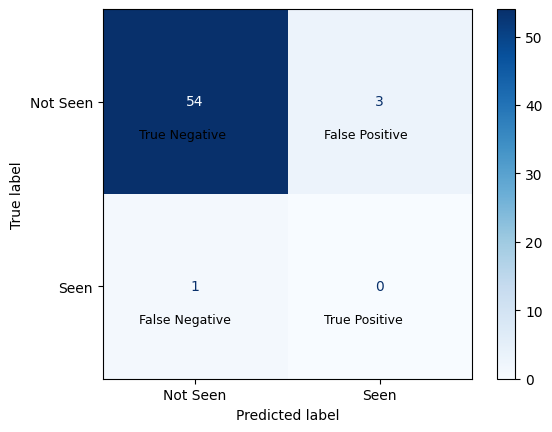

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for plotting

# Generate predictions using the PCA-transformed test data
y_pred = log_reg_pca.predict(X_test)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Define the actual class labels
class_labels = ['Not Seen', 'Seen']

# Create a ConfusionMatrixDisplay object for visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, 
    display_labels=class_labels  # Use actual class labels
)

# Plot the confusion matrix with a blue color map for better readability
plt.figure(figsize=(8, 6))  # Adjust the figure size for better visualization
disp.plot(cmap='Blues', values_format='d')  # Use 'd' to display integer values

# Add labels for True Positive, False Positive, True Negative, and False Negative
plt.text(-0.3, 0.2, 'True Negative', fontsize=9, color='black', ha='left')
plt.text(0.7, 0.2, 'False Positive', fontsize=9, color='black', ha='left')
plt.text(-0.3, 1.2, 'False Negative', fontsize=9, color='black', ha='left')
plt.text(0.7, 1.2, 'True Positive', fontsize=9, color='black', ha='left')

# Ensure numbers in the confusion matrix are not displayed in scientific notation
np.set_printoptions(suppress=True)

# Show the plot
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

# Calculate predicted probabilities
y_pred_proba = log_reg_pca.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"Precision-Recall AUC: {pr_auc:.2f}")

Precision-Recall AUC: 0.25


In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(log_reg_pca, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')

# Print the cross-validation scores and their mean
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores: [0.92134831 0.95505618 0.94382022 0.97752809 0.95454545]
Mean cross-validation score: 0.9504596527068436


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Ensure X_test_pca and y_test have the same number of samples
X_test_pca = X_test.iloc[:len(y_test)]

# Make predictions using the Random Forest model
y_pred_rf = rf.predict(X_test_pca)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Print the evaluation metrics
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"Random Forest Precision: {precision_rf:.2f}")
print(f"Random Forest Recall: {recall_rf:.2f}")
print(f"Random Forest F1 Score: {f1_rf:.2f}")

# Print the classification report
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.98
Random Forest Precision: 0.50
Random Forest Recall: 1.00
Random Forest F1 Score: 0.67

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        57
           1       0.50      1.00      0.67         1

    accuracy                           0.98        58
   macro avg       0.75      0.99      0.83        58
weighted avg       0.99      0.98      0.99        58



In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]))
xgb.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions using the XGBoost model
y_pred_xgb = xgb.predict(X_test)

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Print the evaluation metrics
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}")
print(f"XGBoost Precision: {precision_xgb:.2f}")
print(f"XGBoost Recall: {recall_xgb:.2f}")
print(f"XGBoost F1 Score: {f1_xgb:.2f}")

# Print the classification report
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.98
XGBoost Precision: 0.50
XGBoost Recall: 1.00
XGBoost F1 Score: 0.67

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        57
           1       0.50      1.00      0.67         1

    accuracy                           0.98        58
   macro avg       0.75      0.99      0.83        58
weighted avg       0.99      0.98      0.99        58

